In [73]:
#data handling
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [4]:
#Load Dataset
df=pd.read_csv("student_performance.csv")

In [5]:
df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
0,S0524,21,Female,2.7,74.0,37.0,F
1,S0603,19,Male,1.5,93.1,26.0,F
2,S0527,20,Female,6.8,97.2,88.0,A
3,S0032,18,Female,6.2,93.5,55.0,C
4,S0617,21,Male,7.4,99.2,77.0,B


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1020 non-null   object 
 1   Age            1020 non-null   int64  
 2   Gender         1020 non-null   object 
 3   Study_Hours    989 non-null    float64
 4   Attendance(%)  990 non-null    float64
 5   Test_Score     1020 non-null   float64
 6   Grade          1011 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 55.9+ KB


In [7]:
df.describe()

,Age,Study_Hours,Attendance(%),Test_Score
count,1020.000000,989.000000,990.000000,1020.000000
mean,20.970588,5.160768,84.871919,49.843137
std,2.008109,2.555877,10.007239,21.278630
min,18.000000,-2.000000,50.300000,0.000000
25%,19.000000,3.700000,78.000000,35.000000
50%,21.000000,5.100000,85.000000,50.000000
75%,23.000000,6.300000,91.975000,64.000000
max,24.000000,25.000000,115.600000,100.000000


In [8]:
#columns
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Study_Hours', 'Attendance(%)',
       'Test_Score', 'Grade'],
      dtype='object')

In [11]:
#Checking missing values before handling
df.isnull().sum()

Student_ID        0
Age               0
Gender            0
Study_Hours      31
Attendance(%)    30
Test_Score        0
Grade             9
dtype: int64

In [80]:
#checking duplicated value 
df.duplicated().sum()

np.int64(0)

In [27]:
#Checking unique value
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [28]:
#Checking unique value
df['Grade'].unique()

array(['F', 'A', 'C', 'B', 'A+'], dtype=object)

In [29]:
#Filling the value with mode
df['Grade']=df['Grade'].fillna(df['Grade'].mode()[0])

In [63]:
df['Grade'].isnull().sum()

np.int64(0)

In [64]:
df['Grade'].unique()

array(['F', 'A', 'C', 'B', 'A+'], dtype=object)

In [30]:
#Filling the value with median
df['Study_Hours']=df['Study_Hours'].fillna(df['Study_Hours'].median())

In [31]:
#Checking missing value after handling
df.isnull().sum()

Student_ID       0
Age              0
Gender           0
Study_Hours      0
Attendance(%)    0
Test_Score       0
Grade            0
dtype: int64

In [32]:
#Filling the value with mode
df['Attendance(%)']=df['Attendance(%)'].fillna(df['Attendance(%)'].median())

In [33]:
#Checking missing value after handling
df.isnull().sum()

Student_ID       0
Age              0
Gender           0
Study_Hours      0
Attendance(%)    0
Test_Score       0
Grade            0
dtype: int64

In [34]:
#Listing all dupicates row
df[df.duplicated(keep=False)]

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade


In [35]:
#Drop dupicates value
df.drop_duplicates(inplace=True)

In [36]:
#Checking duplicates value after handling
df.duplicated().sum()

np.int64(0)

In [37]:
#Checking for invalid value or negative value
df[df['Study_Hours']<0]

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
157,S0045,20,Male,-2.0,100.9,4.0,F
619,S0689,18,Female,-0.5,82.2,6.0,F
775,S0497,18,Male,-0.8,77.9,0.0,F
909,S0725,24,Male,-0.7,58.2,0.0,F


In [40]:
# Convert negative Study_Hours values to missing values (NaN)
df.loc[df['Study_Hours']<0,'Study_Hours']=np.nan

In [41]:
#Filling the value with mode
df['Study_Hours']=df['Study_Hours'].fillna(df['Study_Hours'].median())

In [42]:
df.describe()

,Age,Study_Hours,Attendance(%),Test_Score
count,1000.0000,1000.000000,1000.000000,1000.00000
mean,20.9600,5.184100,84.850400,49.80800
std,2.0036,2.491591,9.820518,21.18745
min,18.0000,0.000000,50.300000,0.00000
25%,19.0000,3.700000,78.000000,35.00000
50%,21.0000,5.100000,85.000000,50.00000
75%,23.0000,6.300000,91.725000,64.00000
max,24.0000,25.000000,115.600000,100.00000


In [43]:
#Checking missing value after handling
df.isnull().sum()

Student_ID       0
Age              0
Gender           0
Study_Hours      0
Attendance(%)    0
Test_Score       0
Grade            0
dtype: int64

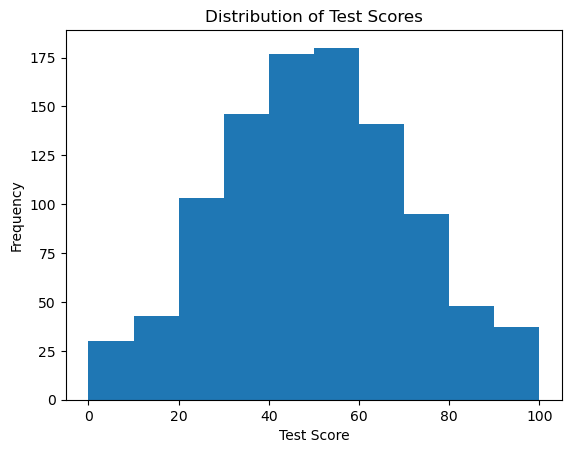

In [44]:
#Visualization part
# Histogram to show the distribution of students' test scores
plt.hist(df['Test_Score'], bins=10)

plt.title('Distribution of Test Scores')
plt.xlabel('Test Score')
plt.ylabel('Frequency')

plt.show()

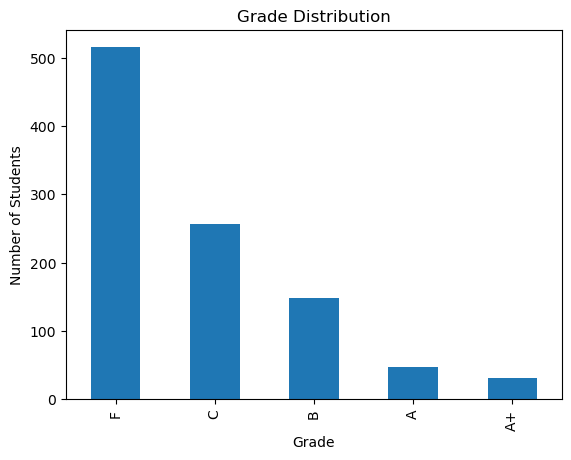

In [46]:
#Bar chart to display the number of students in each grade category
df['Grade'].value_counts().plot(kind='bar')

plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.show()

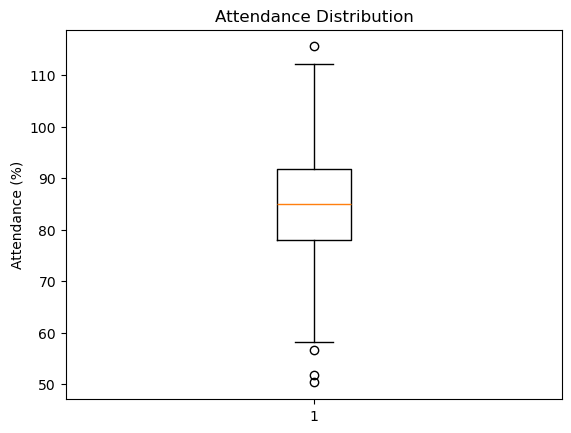

In [66]:
#Box Plot
#Box plot to visualize the distribution of attendance percentages
plt.boxplot(df['Attendance(%)'])

plt.title('Attendance Distribution')
plt.ylabel('Attendance (%)')

plt.show()

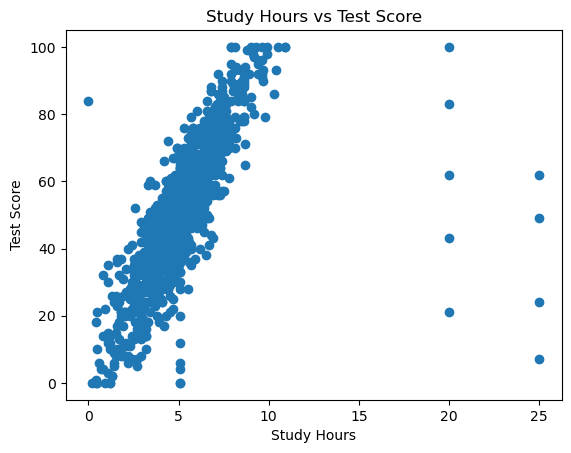

In [70]:
#Scatter Plot
# Scatter plot to examine the relationship between study hours and test scores
plt.scatter(df['Study_Hours'], df['Test_Score'])

plt.title('Study Hours vs Test Score')
plt.xlabel('Study Hours')
plt.ylabel('Test Score')

plt.show()

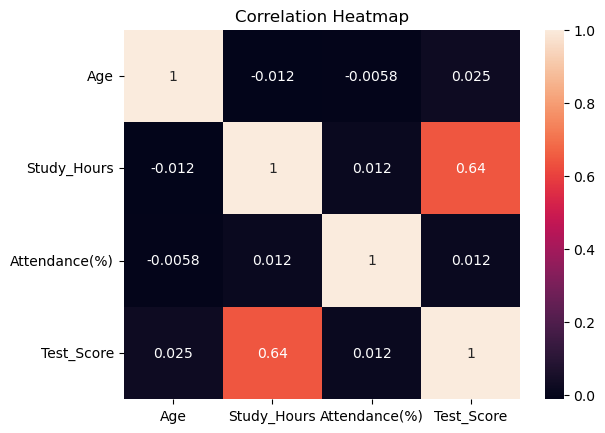

In [51]:
#Correlation Heatmap
# Calculate correlation between numerical variables
corr = df[['Age', 'Study_Hours', 'Attendance(%)', 'Test_Score']].corr()

sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap')

plt.show()

In [85]:
#Descriptive statistics
df.describe()

,Age,Study_Hours,Attendance(%),Test_Score
count,1000.0000,1000.000000,1000.000000,1000.00000
mean,20.9600,5.184100,84.850400,49.80800
std,2.0036,2.491591,9.820518,21.18745
min,18.0000,0.000000,50.300000,0.00000
25%,19.0000,3.700000,78.000000,35.00000
50%,21.0000,5.100000,85.000000,50.00000
75%,23.0000,6.300000,91.725000,64.00000
max,24.0000,25.000000,115.600000,100.00000


In [52]:
#Mean
df.mean(numeric_only=True)

Age              20.9600
Study_Hours       5.1841
Attendance(%)    84.8504
Test_Score       49.8080
dtype: float64

In [53]:
#Median
df.median(numeric_only=True)

Age              21.0
Study_Hours       5.1
Attendance(%)    85.0
Test_Score       50.0
dtype: float64

In [54]:
#Mode
df.mode().iloc[0]

Student_ID       S0001
Age               18.0
Gender            Male
Study_Hours        5.1
Attendance(%)     85.0
Test_Score        49.0
Grade                F
Name: 0, dtype: object

In [55]:
#Standard Deviation
df.std(numeric_only=True)

Age               2.003600
Study_Hours       2.491591
Attendance(%)     9.820518
Test_Score       21.187450
dtype: float64

In [56]:
#Variance
df.var(numeric_only=True)

Age                4.014414
Study_Hours        6.208025
Attendance(%)     96.442582
Test_Score       448.908044
dtype: float64

In [57]:
#Minimum value
df.min(numeric_only=True)

Age              18.0
Study_Hours       0.0
Attendance(%)    50.3
Test_Score        0.0
dtype: float64

In [58]:
#Maximum Value
df.max(numeric_only=True)

Age               24.0
Study_Hours       25.0
Attendance(%)    115.6
Test_Score       100.0
dtype: float64

In [59]:
#Quartile
df.quantile([0.25, 0.5, 0.75], numeric_only=True)

,Age,Study_Hours,Attendance(%),Test_Score
0.25,19.0,3.7,78.000,35.0
0.50,21.0,5.1,85.000,50.0
0.75,23.0,6.3,91.725,64.0


In [60]:
#Inter quartile range
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1
print(IQR)

Age               4.000
Study_Hours       2.600
Attendance(%)    13.725
Test_Score       29.000
dtype: float64


In [77]:
#Hypothesis Formulation and Statistical Testing
#Research Question
#Is there a significant relationship between Study Hours and Test Scores of students?

#Hypotheses
#Null Hypothesis (H₀)
#There is no significant relationship between Study Hours and Test Scores.

#Alternative Hypothesis (H₁)
#There is a significant relationship between Study Hours and Test Scores.

#Statistical Test
#Pearson Correlation Test is used because both variables are numerical.
corr, p_value = stats.pearsonr(df['Study_Hours'], df['Test_Score'])

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

Correlation Coefficient: 0.6408654149843718
P-value: 9.764360275680395e-117


In [78]:
#Decision Rule
#Interpertation
#p-value < 0.05 = significance relationship exists.
#p-value > 0.05 = No significance relationship.
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [ ]:
#Interpretation and Conclusion

#1.Interpretation of Findings
Descriptive statistics showed averages, variation, and data spread for Study Hours, Attendance, and Test Scores. 
Visualizations (histogram, bar chart, box plot, scatter plot, and heatmap) helped show distributions, outliers, and relationships. 
A Pearson Correlation Test showed a moderate positive relationship between Study Hours and Test Scores (**r = 0.6409, p < 0.05**),
which is statistically significant.

#2.Key Insights
1.More study hours improve test scores
2.Study hours and scores are positively correlated
3.Attendance also supports performance
4.Students show variation in performance
5.Visuals clearly showed patterns

#3.Conclusion
There is a significant positive relationship between Study Hours and Test Scores. Better study habits and attendance lead to improved academic
performance.